# Model 1a - Logistic Regression

  **Stage 6 + 7** - model development, comparison and optimisation

A linear, interpretable baseline. Its coefficients are easy to explain to non-technical stakeholders, and it shows how much of the signal is simple/linear.

> **How to run:** first set `DATA_FRAC = 0.1` to check that everything works (a few minutes), then set it to `1.0` and *Run All* for the real results.
> Everything here uses the shared code in `src/` - same split, same 5 folds, same metrics as the other members.

## 1. Setup and data

In [3]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
from common import *
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif

NAME = "Logistic Regression"

# ---- run configuration ---------------------------------------------------------------------------
DATA_FRAC        = 1.0    # share of TRAINING patients used in this notebook (0.1 = quick check run)
EXP_FRAC         = 0.3    # share of patients used for the small experiments in section 4
TUNE_SAMPLE_FRAC = 0.3    # share of patients used DURING the search (the best model is refitted on ALL data)
N_ITER           = 10     # candidates tried by random / halving search
SEARCH_METHOD    = "grid"   # "random" | "grid" | "halving"
# --------------------------------------------------------------------------------------------------
reset_log(NAME)

In [4]:
X_train, X_test, y_train, y_test, g_train, cv, class_names = load_and_split()
X_train, y_train, g_train = patient_subsample(X_train, y_train, g_train, DATA_FRAC)
X_exp, y_exp, g_exp = patient_subsample(X_train, y_train, g_train, EXP_FRAC)
print("train", X_train.shape, "| test", X_test.shape, "| classes", class_names)
pd.Series(y_train).map(dict(enumerate(class_names))).value_counts(normalize=True).round(3)

train (79541, 50) | test (19802, 50) | classes ['<30', '>30', 'NO']


NO     0.528
>30    0.357
<30    0.114
Name: proportion, dtype: float64

## 2. Why this model? (algorithm selection and justification)

- **Task fit:** multinomial logistic regression handles the 3-class target directly and outputs probabilities (needed for ROC-AUC / PR-AUC and for the prediction system).
- **Data fit:** works well on a large, sparse one-hot matrix; numeric features are standardised (the preprocessor does this) because the model is scale-sensitive.
- **Strengths:** fast, interpretable coefficients, hard to over-fit with regularisation. **Weaknesses:** only linear effects - cannot capture interactions (e.g. age x previous visits) unless engineered.
- **Role in the project:** the baseline every other model must beat.

## 3. Baseline model and validation strategy
- **Validation:** 5-fold `StratifiedGroupKFold` on the training set, grouped by `patient_nbr` (a patient never appears in both the training and validation part of a fold) and stratified (the rare `<30` class, about 11%, appears in every fold). The folds are fixed (`random_state=42`) and identical for every model.
- **Preprocessing inside the pipeline:** imputation, scaling and one-hot encoding are refitted on the training part of each fold, so nothing leaks from the validation part.
- **Imbalance:** handled with class weights, not by resampling (SMOTE works poorly on ~2,400 sparse one-hot columns).
- **Main metric: macro-F1** (every class counts equally). Accuracy is misleading here because always predicting `NO` already scores about 55%. We also track macro-recall, ROC-AUC (one-vs-rest) and PR-AUC / recall for the `<30` class.
- The **test set is not touched** until section 6.

In [5]:
def make_pipe(**kw):
    params = dict(C=1.0, max_iter=300, class_weight="balanced")
    params.update(kw)
    return Pipeline([("pre", make_preprocessor(scale=True)),
                     ("m", LogisticRegression(**params))])


pipe = make_pipe()
baseline = cv_evaluate(pipe, X_train, y_train, g_train, cv)
pd.Series({k: round(v, 4) for k, v in baseline.items() if not isinstance(v, list)})

cv_macro_f1           0.4239
cv_weighted_f1        0.4978
cv_macro_recall       0.4482
cv_macro_precision    0.4327
cv_accuracy           0.4794
cv_roc_auc_ovr        0.6408
cv_pr_auc_lt30        0.1958
cv_recall_lt30        0.4042
cv_precision_lt30     0.1826
cv_f1_lt30            0.2515
cv_macro_f1_std       0.0042
cv_pr_auc_lt30_std    0.0084
train_macro_f1        0.4643
fit_time_s            6.7231
dtype: float64

### Baseline observations
The baseline Logistic Regression model achieved a cross-validation macro-F1 score of 0.4239 and macro-recall of 0.4482, indicating moderate overall classification performance. The ROC-AUC of 0.6408 shows that the model has some ability to discriminate between the three classes. However, the model performs poorly on the minority <30 class, with a precision of 0.1826, recall of 0.4042, and F1-score of 0.2515. The small difference between training macro-F1 (0.4643) and cross-validation macro-F1 (0.4239), together with the low CV standard deviation (0.0042), suggests that the model is relatively stable and is not suffering from severe overfitting. Therefore, further optimisation of regularisation, class weighting, feature selection, and categorical feature treatment is justified.


## 4. Experiments - understanding why the model behaves the way it does
Each experiment is cross-validated with the same folds on a patient sample (`EXP_FRAC`) and is saved automatically to `outputs/results/<model>_experiments.csv` (this is your experiment record for the report).

### Experiment 1
**Regularisation strength `C`** (small C = strong regularisation). Watch the gap between train and CV score.

[C sweep] C sweep=0.001: macro-F1=0.4215 (train 0.4317)
[C sweep] C sweep=0.01: macro-F1=0.4269 (train 0.4556)
[C sweep] C sweep=0.1: macro-F1=0.4254 (train 0.4870)
[C sweep] C sweep=1: macro-F1=0.4170 (train 0.5061)
[C sweep] C sweep=10: macro-F1=0.4081 (train 0.5088)


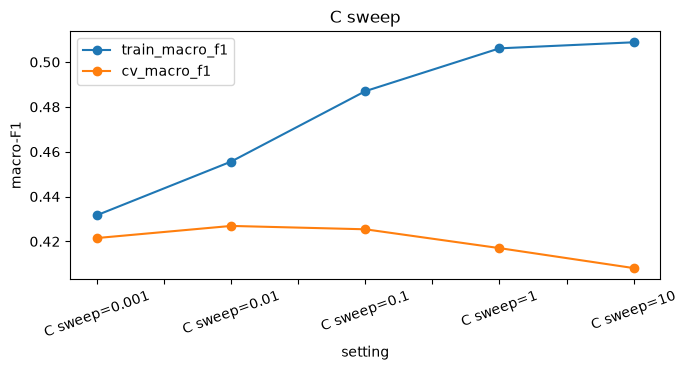

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,C sweep,C sweep=0.001,0.4215,0.4317,0.4460,0.6480,0.1991,0.5586
1,C sweep,C sweep=0.01,0.4269,0.4556,0.4501,0.6503,0.2000,0.7250
2,C sweep,C sweep=0.1,0.4254,0.4870,0.4462,0.6407,0.1916,1.6343
3,C sweep,C sweep=1,0.4170,0.5061,0.4362,0.6222,0.1735,2.1265
4,C sweep,C sweep=10,0.4081,0.5088,0.4273,0.6111,0.1630,2.0802


In [6]:
sweep(NAME, "C sweep", [0.001, 0.01, 0.1, 1, 10], lambda v: make_pipe(C=v), X_exp, y_exp, g_exp, cv)

CV Macro-F1 was highest at C = 0.01, while larger C values increased training performance but reduced CV performance.
C = 0.01 is the best choice among the tested values and provides better generalisation.


### Experiment 2
**Class weights vs none** - how does handling imbalance change macro-F1, macro-recall and accuracy?

In [7]:
for cw in ["balanced", None]:
    run_experiment(NAME, "Class weight", f"class_weight={cw}", make_pipe(class_weight=cw), X_exp, y_exp, g_exp, cv)
show_experiments(NAME, "Class weight")

[Class weight] class_weight=balanced: macro-F1=0.4170 (train 0.5061)
[Class weight] class_weight=None: macro-F1=0.3975 (train 0.4583)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Class weight,class_weight=balanced,0.4170,0.5061,0.4362,0.6222,0.1735,2.1434
1,Class weight,class_weight=None,0.3975,0.4583,0.4097,0.6353,0.1820,2.0678


The balanced and unbalanced models were compared to see how class weighting affects minority-class performance.
Class weighting should be selected based on Macro-F1 and <30 performance, not accuracy alone.

### Experiment 3
**Feature selection** - keep only the K best features (ANOVA F-test, selected inside each fold, so no leakage). Does removing features help or hurt?

[Top-K features] Top-K features=50: macro-F1=0.4217 (train 0.4333)
[Top-K features] Top-K features=200: macro-F1=0.4249 (train 0.4572)
[Top-K features] Top-K features=500: macro-F1=0.4248 (train 0.4808)
[Top-K features] Top-K features=1000: macro-F1=0.4196 (train 0.4949)


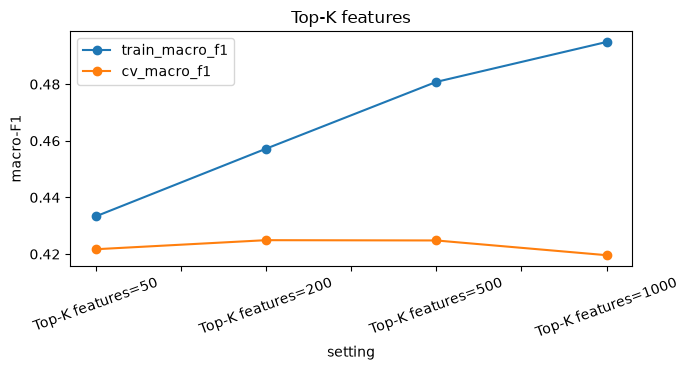

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Top-K features,Top-K features=50,0.4217,0.4333,0.4428,0.6459,0.1982,0.8597
1,Top-K features,Top-K features=200,0.4249,0.4572,0.4433,0.6406,0.1879,1.2996
2,Top-K features,Top-K features=500,0.4248,0.4808,0.4442,0.6343,0.1817,2.8446
3,Top-K features,Top-K features=1000,0.4196,0.4949,0.4393,0.6285,0.1764,3.3131


In [8]:
def make_selected(k):
    return Pipeline([("pre", make_preprocessor(scale=True)),
                     ("sel", SelectKBest(f_classif, k=k)),
                     ("m", LogisticRegression(C=1.0, max_iter=300, class_weight="balanced"))])
sweep(NAME, "Top-K features", [50, 200, 500, 1000], make_selected, X_exp, y_exp, g_exp, cv)

Different numbers of top features were tested to determine whether reducing features improves CV performance.
The feature count with the highest CV Macro-F1 should be selected for the final model.

### Experiment 4
**Feature encoding** - `admission_type_id`, `discharge_disposition_id` and `admission_source_id` are numeric *codes*, not quantities. What happens if they are treated as categories?

In [9]:
ID_CODES = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
X_alt = X_exp.copy()
for col in ID_CODES:
    X_alt[col] = X_alt[col].astype(str)
run_experiment(NAME, "ID codes", "as numbers", make_pipe(), X_exp, y_exp, g_exp, cv)
run_experiment(NAME, "ID codes", "as categories", make_pipe(), X_alt, y_exp, g_exp, cv)
show_experiments(NAME, "ID codes")

[ID codes] as numbers: macro-F1=0.4170 (train 0.5061)
[ID codes] as categories: macro-F1=0.4267 (train 0.5156)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,ID codes,as numbers,0.4170,0.5061,0.4362,0.6222,0.1735,2.3072
1,ID codes,as categories,0.4267,0.5156,0.4468,0.6328,0.1834,2.2443


ID variables were tested as numerical and categorical features to compare their effect on model performance.
The representation with the higher CV Macro-F1 is preferred, with categorical treatment generally avoiding false numerical relationships.

## 5. Hyper-parameter tuning (Stage 7)
**Search strategy:** **Grid search.** Logistic regression has a tiny search space (C x class weight = 10 combinations), so an exhaustive grid is affordable and fully reproducible; random search would add nothing.

Scoring is **macro-F1** with the same grouped folds. To keep the search fast, it runs on `TUNE_SAMPLE_FRAC` of the patients and the best configuration is then **refitted on all training data**. The tuned model is re-evaluated with the full 5-fold CV so that baseline and tuned scores are directly comparable.

In [10]:
space = {"m__C": [0.01, 0.03, 0.1, 0.3, 1.0],
         "m__class_weight": ["balanced", None]}


tune_res = tune(pipe, space, X_train, y_train, g_train, cv,
                method=SEARCH_METHOD, n_iter=N_ITER, sample_frac=TUNE_SAMPLE_FRAC)
print("Best parameters:", tune_res.best_params_)
print(f"Search took {tune_res.search_time_s/60:.1f} min")
top_configs(tune_res)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'m__C': 0.03, 'm__class_weight': 'balanced'}
Search took 1.4 min


,param_m__C,param_m__class_weight,mean_test_score,std_test_score
2,0.03,balanced,0.4286,0.0079
0,0.01,balanced,0.4269,0.0078
4,0.10,balanced,0.4254,0.0074
6,0.30,balanced,0.4214,0.0067
8,1.00,balanced,0.4170,0.0071


In [12]:
tuned = cv_evaluate(tune_res.best_estimator_, X_train, y_train, g_train, cv)   # full 5-fold CV, comparable with baseline
compare_table(baseline, tuned)

,baseline,tuned,change
CV macro-F1 (main metric),0.4239,0.4294,0.0054
CV macro-recall,0.4482,0.4544,0.0062
CV accuracy,0.4794,0.4911,0.0117
"CV ROC-AUC (OvR, macro)",0.6408,0.6534,0.0126
CV PR-AUC for <30,0.1958,0.2085,0.0126
CV recall for <30,0.4042,0.4102,0.0060
Train macro-F1 (over-fit check),0.4643,0.4527,-0.0116
Fit time per fold (s),6.7231,4.7496,-1.9735


The tuned model with C = 0.03 and class_weight = balanced achieved the highest CV Macro-F1 (0.4294) compared with the baseline (0.4239). Other metrics, including macro-recall, ROC-AUC, and <30 PR-AUC, also improved, while Train Macro-F1 decreased from 0.4643 to 0.4527.

Hyperparameter tuning improved the model's generalisation performance, with C = 0.03 and balanced class weights selected as the best configuration. The lower training Macro-F1 also suggests less overfitting.



## 6. Final evaluation on the untouched test set (reported once)
The final model of the project is chosen later, in `compare_models.ipynb`, by **CV score - not by test score**.

              precision    recall  f1-score   support

         <30      0.192     0.422     0.264      2216
         >30      0.474     0.347     0.400      7090
          NO      0.661     0.614     0.637     10496

    accuracy                          0.497     19802
   macro avg      0.442     0.461     0.434     19802
weighted avg      0.541     0.497     0.510     19802



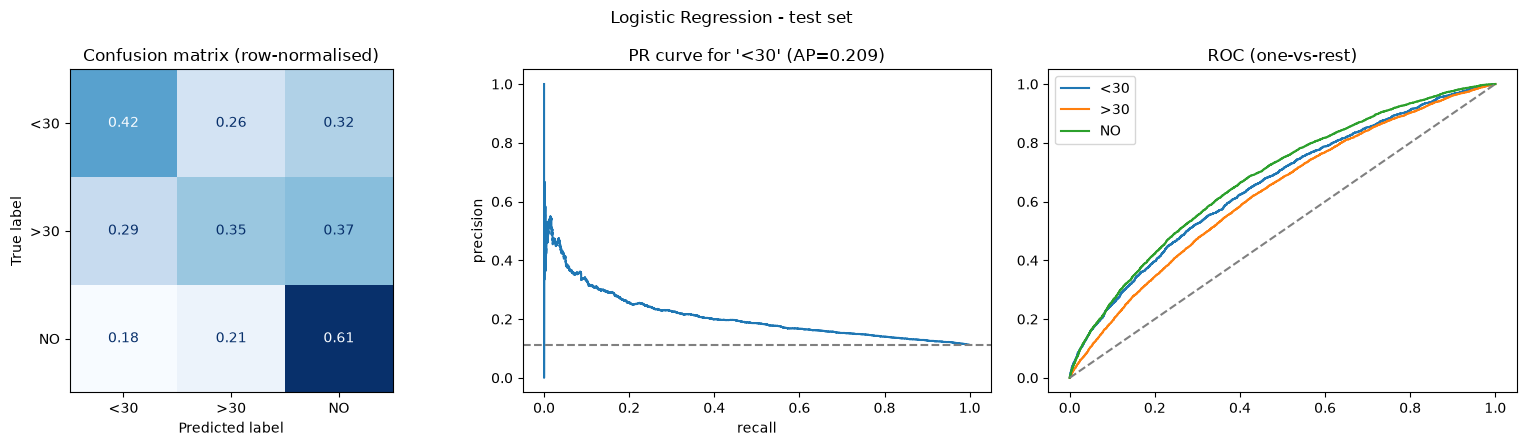

Saved outputs/results/logistic_regression.json and outputs/models/logistic_regression.joblib


In [13]:
result = finalize(NAME, baseline, tuned, tune_res, X_test, y_test, class_names)

## 7. Interpretation

Features pushing the prediction AWAY from <30 (negative) and TOWARDS <30 (positive):


,feature,value
367,categorical__diag_1_386,-0.303
1298,categorical__diag_2_728,-0.300
83,categorical__medical_specialty_Otolaryngology,-0.267
222,categorical__diag_1_250.02,-0.264
486,categorical__diag_1_535,-0.243
816,categorical__diag_1_V55,-0.242
1840,categorical__diag_3_466,-0.228
506,categorical__diag_1_566,-0.226
405,categorical__diag_1_434,0.284
902,categorical__diag_2_250.03,0.285


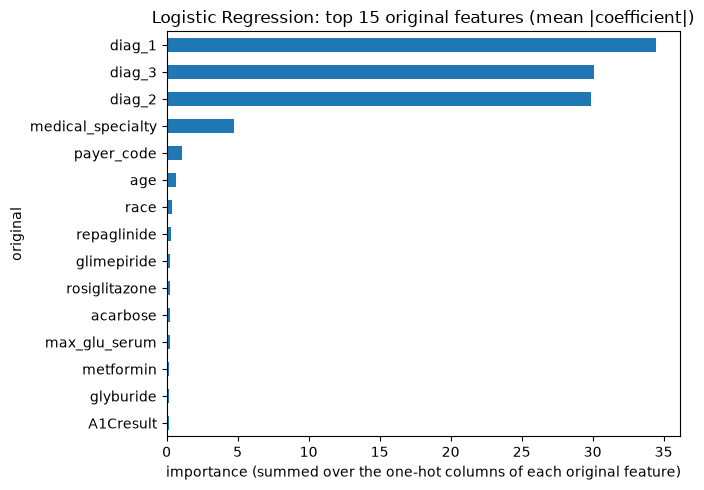

In [11]:
best = tune_res.best_estimator_
tbl = feature_importance_table(best, X_train.columns, class_index=0)      # coefficients for the '<30' class
ordered = tbl.sort_values("value")
print("Features pushing the prediction AWAY from <30 (negative) and TOWARDS <30 (positive):")
display(pd.concat([ordered.head(8), ordered.tail(8)])[["feature", "value"]].round(3))
top = top_original_features(feature_importance_table(best, X_train.columns), 15)
plot_top_features(top, f"{NAME}: top 15 original features (mean |coefficient|)", NAME)


- Where does this model perform well / badly, per class? Why?
- What did the experiments show about over-fitting, imbalance and feature choices?
- Do the important features make clinical sense?



- Why is logistic regression a good baseline? What does `C` control?
- Why standardise numeric features for this model but not for trees?
- What did the feature-selection and class-weight experiments show?
- What does a positive coefficient for `<30` mean for a hospital?
- Why macro-F1 instead of accuracy?